In [3]:
import pandas as pd
df = pd.read_csv("D:\\Store - sales pro\\Store Item Demand Forecasting Challenge.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.shape

(913000, 4)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries ready ✅")

All libraries ready ✅


In [6]:
print("\nColumns:", df.columns.tolist())


Columns: ['date', 'store', 'item', 'sales']


In [8]:
df.info()
print("\nNull values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB

Null values:
 date     0
store    0
item     0
sales    0
dtype: int64


In [9]:
# Convert date column to datetime (change 'date' to your actual column name)
df['date'] = pd.to_datetime(df['date'])

# Set as index
df = df.sort_values('date')
df.set_index('date', inplace=True)

print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-01,7,12,26
2013-01-01,7,46,27
2013-01-01,8,12,54
2013-01-01,9,12,35


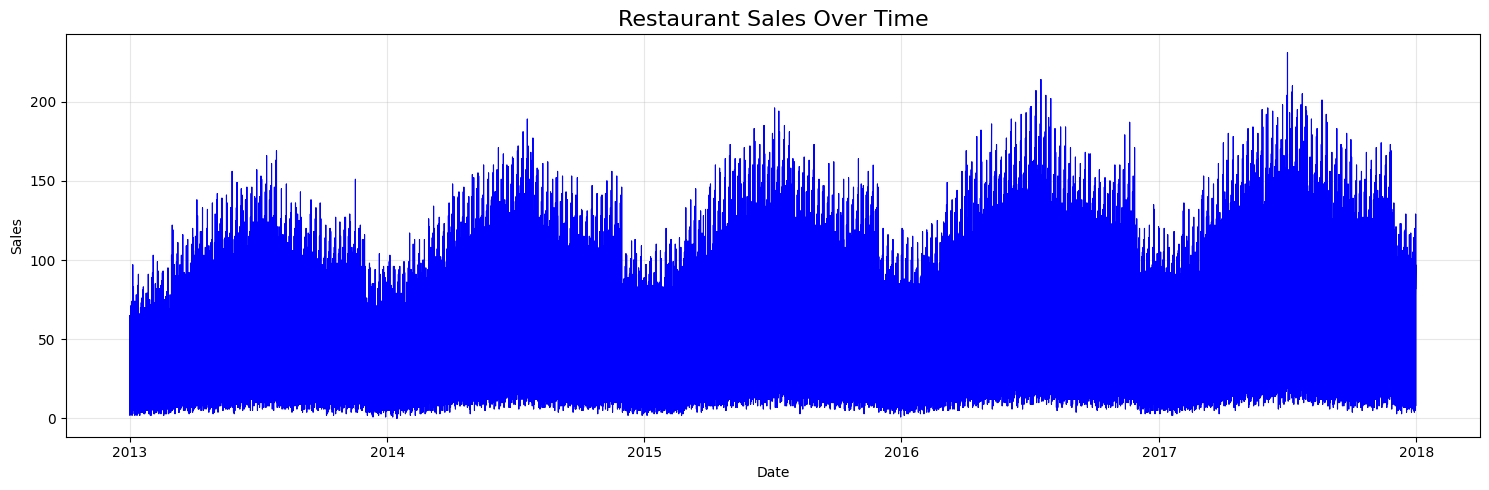

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['sales'], color='blue', linewidth=0.8)
plt.title('Restaurant Sales Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

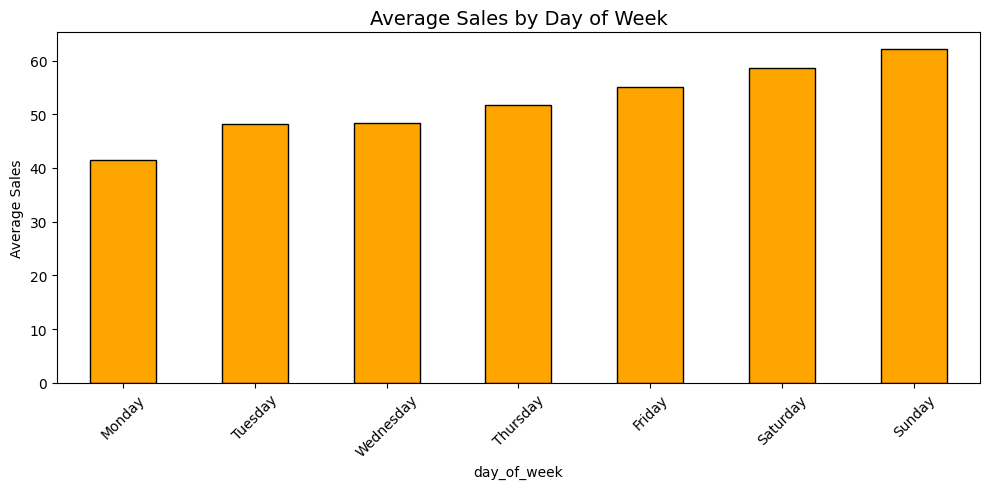

In [11]:
# Add day of week column
df['day_of_week'] = df.index.day_name()

# Average sales by day
day_avg = df.groupby('day_of_week')['sales'].mean()

# Order days correctly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = day_avg.reindex(days_order)

plt.figure(figsize=(10, 5))
day_avg.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Sales by Day of Week', fontsize=14)
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

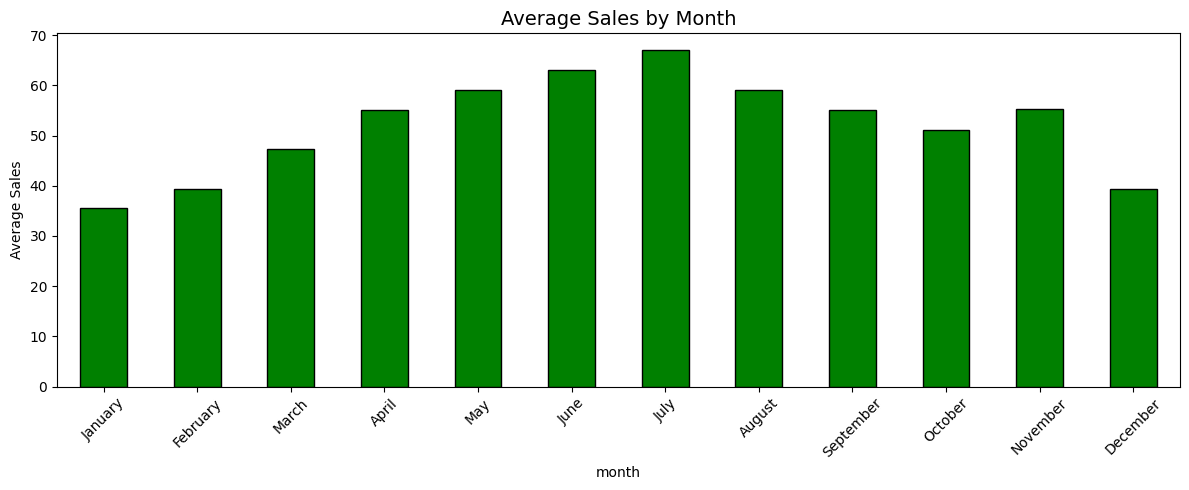

In [12]:
df['month'] = df.index.month_name()

month_avg = df.groupby('month')['sales'].mean()

months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
month_avg = month_avg.reindex(months_order)

plt.figure(figsize=(12, 5))
month_avg.plot(kind='bar', color='green', edgecolor='black')
plt.title('Average Sales by Month', fontsize=14)
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()